## EV Route Finding System

## Initial Neighbor Finding Code

In [1]:
import pandas as pd
import networkx as nx
from geopy.distance import geodesic
import random
from sklearn.cluster import DBSCAN
import numpy as np
from collections import defaultdict
import math
import pickle

In [ ]:
# Keep only stations with valid coordinates and charger counts
df = pd.read_csv("./ev-charging-station.csv")
df_clean = df.dropna(subset=['Latitude', 'Longitude', 'EV Level2 EVSE Num', 'EV Connector Types']).reset_index(drop=True)
df_clean['EV Level2 EVSE Num'] = df_clean['EV Level2 EVSE Num'].astype(int)

# Parse connector types into sets
df_clean['connector_set'] = df_clean['EV Connector Types'].apply(lambda x: set(map(str.strip, x.split(','))) if isinstance(x, str) else set())

# Clustering
coords = df_clean[['Latitude', 'Longitude']].to_numpy()
kms_per_radian = 6371.0088
epsilon = 20.0 / kms_per_radian  # ~20 km radius
db = DBSCAN(eps=epsilon, min_samples=1, algorithm='ball_tree', metric='haversine').fit(np.radians(coords))
df_clean['cluster'] = db.labels_

# Group by cluster and aggregate
df_clustered = df_clean.groupby('cluster').agg({
    'Latitude': 'mean',
    'Longitude': 'mean',
    'EV Level2 EVSE Num': 'sum',
    'connector_set': lambda sets: set().union(*sets)
}).reset_index(drop=True)

G = nx.Graph()
for idx, row in df_clustered.iterrows():
    G.add_node(
        idx,
        pos=(row['Latitude'], row['Longitude']),
        chargers=row['EV Level2 EVSE Num'],
        connector_types=row['connector_set']
    )

def distance(i, j):
    return geodesic(G.nodes[i]['pos'], G.nodes[j]['pos']).km

def angle_between(lat1, lon1, lat2, lon2):
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    angle = math.degrees(math.atan2(dlon, dlat)) % 360
    return angle

# number of nearest neighbors per node
k = 5

print("Graph node count:", len(G.nodes))
print("Connecting each node to its", k, "nearest neighbors...")

for i in G.nodes:
    distances = []
    lat1, lon1 = G.nodes[i]['pos']

    for j in G.nodes:
        if i == j:
            continue
        lat2, lon2 = G.nodes[j]['pos']
        dist = distance(i, j)
        distances.append((dist, j))

    distances.sort()
    nearest_neighbors = [j for _, j in distances[:k]]

    for j in nearest_neighbors:
        dist = distance(i, j)
        weight = dist / (1 + G.nodes[j]['chargers'])
        G.add_edge(i, j, weight=weight)

    print(f"Node {i} → Neighbors: {nearest_neighbors}")

# Save
with open("graph_data.gpickle", "wb") as f:
    pickle.dump(G, f)

C:\Users\Sarvesh Ram Kumar\AppData\Local\Temp\ipykernel_8252\3988376000.py:2: DtypeWarning: Columns (5,6,26,38,48,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./ev-charging-station.csv")


Graph node count: 2076
Connecting each node to its 5 nearest neighbors...
Node 0 → Neighbors: [743, 101, 131, 1464, 773]
Node 1 → Neighbors: [1723, 2048, 1544, 1995, 845]
Node 2 → Neighbors: [1601, 725, 578, 718, 228]
Node 3 → Neighbors: [470, 1591, 255, 817, 162]
Node 4 → Neighbors: [372, 556, 249, 300, 1042]
Node 5 → Neighbors: [1174, 908, 1254, 359, 191]
Node 6 → Neighbors: [929, 473, 315, 1807, 740]
Node 7 → Neighbors: [1874, 1718, 1034, 1101, 651]
Node 8 → Neighbors: [557, 348, 1877, 1833, 1430]
Node 9 → Neighbors: [1889, 1165, 1360, 595, 625]
Node 10 → Neighbors: [591, 1158, 528, 1751, 700]
Node 11 → Neighbors: [609, 1105, 342, 1663, 1373]
Node 12 → Neighbors: [1484, 1261, 1647, 1059, 1498]
Node 13 → Neighbors: [1576, 1626, 545, 468, 1548]
Node 14 → Neighbors: [798, 1590, 1231, 1800, 1129]
Node 15 → Neighbors: [1102, 523, 282, 1891, 1868]
Node 16 → Neighbors: [1778, 467, 1210, 1224, 1117]
Node 17 → Neighbors: [1554, 1773, 1959, 1479, 881]
Node 18 → Neighbors: [1871, 582, 1084, 19

In [2]:
# Load
with open("graph_data.gpickle", "rb") as f:
    G = pickle.load(f)

## Comparing with Other Existing Models like Google maps and A* Models to show Productivity

## Modified Dijkstra Model for Comparison

In [3]:
import heapq
from geopy.distance import geodesic

def find_nearest_node(lat, lon):
    return min(G.nodes, key=lambda n: geodesic((lat, lon), G.nodes[n]['pos']).km)

def modified_dijkstra_ev(G, start, goal, vehicle_range=200):
    """
    Modified Dijkstra for EVs:
    - Finds the minimum total distance to the goal
    - Accounts for battery range and recharge opportunities
    - Does NOT use heuristic (unlike A*)
    """
    # Priority queue: (distance_so_far, current_node, battery_left, charges_used, path)
    queue = [(0, start, vehicle_range, 0, [])]

    # Track best known distances for each (node, battery) state
    visited = {}

    while queue:
        distance_so_far, current, battery_left, charges_used, path = heapq.heappop(queue)
        path = path + [current]

        # If this state was seen with better distance, skip it
        state_key = (current, battery_left)
        if state_key in visited and visited[state_key] <= distance_so_far:
            continue

        visited[state_key] = distance_so_far

        if current == goal:
            return path, distance_so_far, charges_used

        for neighbor in G.neighbors(current):
            dist = geodesic(G.nodes[current]['pos'], G.nodes[neighbor]['pos']).km

            if dist > battery_left:
                continue  # Not enough charge to reach neighbor

            # Move without recharging
            new_battery = battery_left - dist
            new_distance = distance_so_far + dist
            new_charges_used = charges_used

            # Recharge if there's a charger
            if G.nodes[neighbor].get("chargers", 0) > 0:
                new_battery = vehicle_range
                new_charges_used += 1

            heapq.heappush(queue, (new_distance, neighbor, new_battery, new_charges_used, path))

    return None, float('inf'), 0  # No path found

start_lat, start_lon = 28.54, -81.37   # Orlando, FL (approx.)
end_lat, end_lon = 33.75, -84.39       # Atlanta, GA (approx.)

start_node = find_nearest_node(start_lat, start_lon)
goal_node = find_nearest_node(end_lat, end_lon)
mod_dijkstra_path, mod_dijkstra_dist, mod_dijkstra_charges = modified_dijkstra_ev(G, start_node, goal_node)

if mod_dijkstra_path:
    print("\nModified Dijkstra EV Path:", mod_dijkstra_path)
    print(f"Total Distance Traveled: {mod_dijkstra_dist:.2f} km")
    print(f"Total Steps (Nodes): {len(mod_dijkstra_path)}")
    print(f"Charging Stops Made: {mod_dijkstra_charges}")
    with open("ev-routing-coordinates-ModifiedDij.txt", "w") as f:
        for node in mod_dijkstra_path:
            lat, lon = G.nodes[node]['pos']
            f.write(f"{lon},{lat}\n")  # Lon,Lat format
        print("Coordinates written to ev-routing-coordinates-ModifiedDij.txt")
else:
    print("No path found.")


Modified Dijkstra EV Path: [16, 1117, 1953, 719, 805, 942, 910, 257, 1181, 527, 315, 6]
Total Distance Traveled: 790.31 km
Total Steps (Nodes): 12
Charging Stops Made: 11
Coordinates written to ev-routing-coordinates-ModifiedDij.txt


## On-Road Distance Analysis(Actual Accuracy of the Model) using ORS:

Route from point 0 to 1: 123093.70 m
Route from point 1 to 2: 32808.70 m
Route from point 2 to 3: 102008.70 m
Route from point 3 to 4: 113190.10 m
Route from point 4 to 5: 95549.60 m
Route from point 5 to 6: 63509.70 m
Route from point 6 to 7: 80301.10 m
Route from point 7 to 8: 43978.20 m
Route from point 8 to 9: 93024.70 m
Route from point 9 to 10: 78230.40 m
Route from point 10 to 11: 99464.80 m

✅ Total real-world road distance: 925.16 km


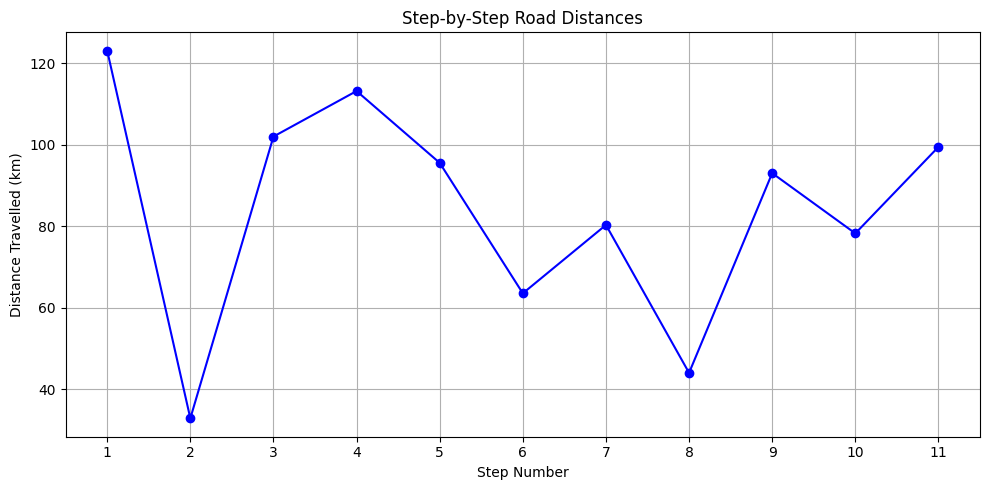

In [ ]:
import openrouteservice

# Replace with your actual OpenRouteService API key
ORS_API_KEY = "API-Key"

# Load coordinates (in (lat, lon) format)
coords = []
with open("ev-routing-coordinates-ModifiedDij.txt", "r") as f:
    for line in f:
        lon, lat = map(float, line.strip().split(','))
        coords.append((lon, lat))  # ORS expects (lon, lat)

# Initialize ORS client
client = openrouteservice.Client(key=ORS_API_KEY)

import matplotlib.pyplot as plt

total_distance = 0
start_idx = 0
step_distances = []

for end_idx in range(1, len(coords)):
    try:
        res = client.directions(
            coordinates=[coords[start_idx], coords[end_idx]],
            profile='driving-car',
            format='geojson',
            radiuses=[1000, 1000]
        )
        dist = res['features'][0]['properties']['segments'][0]['distance']  # in meters
        total_distance += dist
        step_distances.append(dist / 1000)  # convert to kilometers
        print(f"Route from point {start_idx} to {end_idx}: {dist:.2f} m")

        start_idx = end_idx  # Move to next valid start point
    except Exception as e:
        print(f"⚠️ No route from point {start_idx} to {end_idx}: skipping point {end_idx}")

print(f"\n✅ Total real-world road distance: {total_distance/1000:.2f} km")

# Plot step-wise distances
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(step_distances)+1), step_distances, marker='o', linestyle='-', color='blue')
plt.title("Step-by-Step Road Distances")
plt.xlabel("Step Number")
plt.ylabel("Distance Travelled (km)")
plt.grid(True)
plt.xticks(range(1, len(step_distances)+1))
plt.tight_layout()
plt.show()


In [5]:
on_road=710
total_distance=total_distance/1000
print(f"Actual Accuracy:{(on_road/total_distance):.2%}")

Actual Accuracy:76.74%


## Plotting

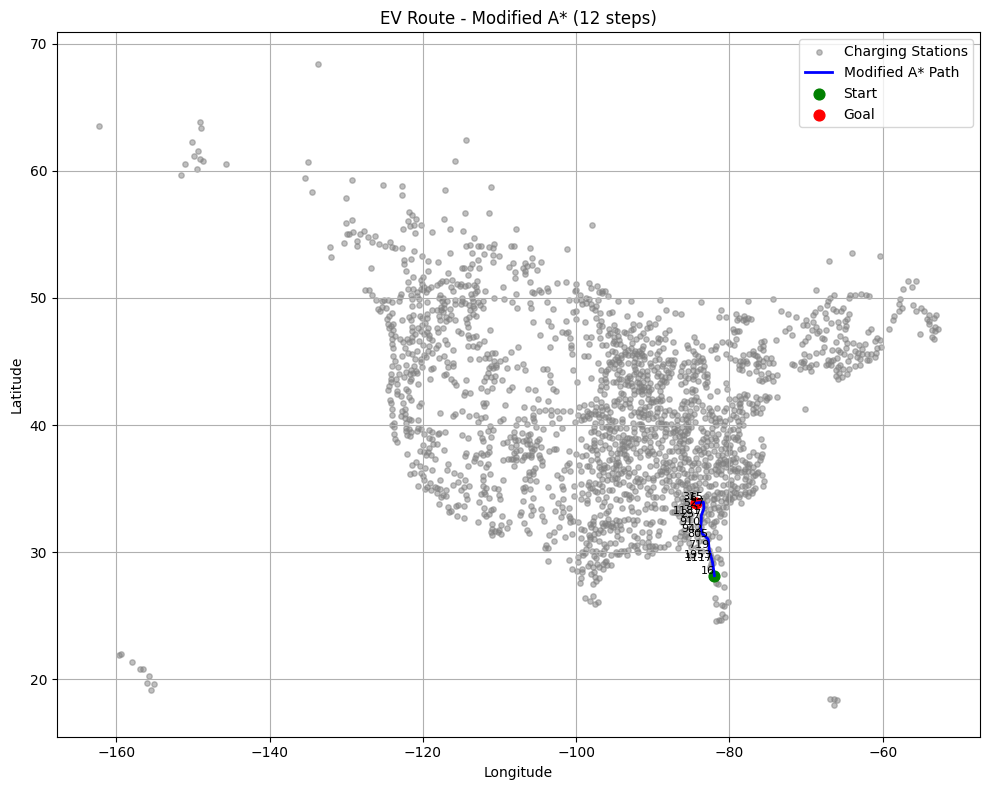

In [6]:
import matplotlib.pyplot as plt

def plot_ev_route(G, path, start_node, goal_node):
    if not path:
        print("No path to plot.")
        return

    # Extract positions for plotting
    node_positions = {n: G.nodes[n]['pos'][::-1] for n in G.nodes}  # lon, lat
    path_coords = [node_positions[n] for n in path]

    # Plot all nodes (charging stations)
    all_x = [pos[0] for pos in node_positions.values()]
    all_y = [pos[1] for pos in node_positions.values()]
    plt.figure(figsize=(10, 8))
    plt.scatter(all_x, all_y, c='gray', alpha=0.5, label='Charging Stations', s=15)

    # Plot the path
    path_x = [coord[0] for coord in path_coords]
    path_y = [coord[1] for coord in path_coords]
    plt.plot(path_x, path_y, c='blue', linewidth=2, label='Modified A* Path')

    # Mark start and goal
    plt.scatter(path_x[0], path_y[0], c='green', s=60, label='Start')
    plt.scatter(path_x[-1], path_y[-1], c='red', s=60, label='Goal')

    # Add node number labels next to nodes in the path
    for node, x, y in zip(path, path_x, path_y):
        plt.text(x, y, str(node), fontsize=8, verticalalignment='bottom', horizontalalignment='right', color='black')

    plt.title(f"EV Route - Modified A* ({len(path)} steps)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 🟢 Example usage:
plot_ev_route(G, mod_dijkstra_path, start_node, goal_node)



## Plotting with USA Map

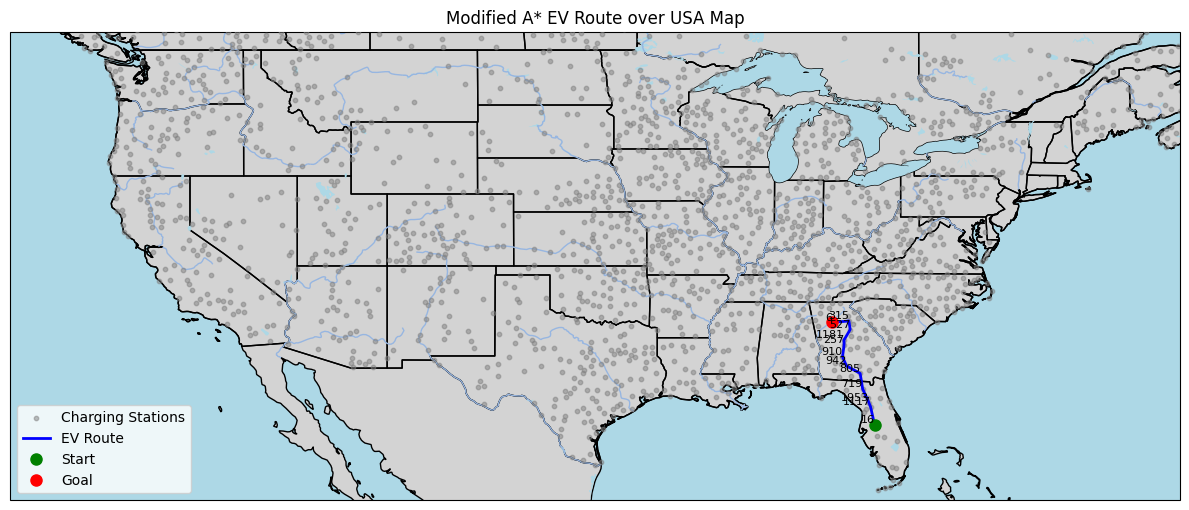

In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
def plot_ev_route_cartopy(G, path):
    if not path:
        print("No path to plot.")
        return

    # Extract positions
    node_positions = {n: G.nodes[n]['pos'] for n in G.nodes}
    path_coords = [node_positions[n] for n in path]

    # Setup plot
    fig = plt.figure(figsize=(12, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Add map features
    ax.set_extent([-130, -65, 24, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES, edgecolor='black')
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.LAKES, facecolor='lightblue')
    ax.add_feature(cfeature.RIVERS)

    # Plot all stations
    all_lat, all_lon = zip(*node_positions.values())
    ax.scatter(all_lon, all_lat, color='gray', s=10, label="Charging Stations", alpha=0.5, zorder=3)

    # Plot route
    path_lat, path_lon = zip(*path_coords)
    ax.plot(path_lon, path_lat, color='blue', linewidth=2, label="EV Route", zorder=5)

    # Plot start and goal
    ax.plot(path_lon[0], path_lat[0], 'go', markersize=8, label="Start", zorder=6)
    ax.plot(path_lon[-1], path_lat[-1], 'ro', markersize=8, label="Goal", zorder=6)

    # Add node number labels next to nodes in the path
    for node, lat, lon in zip(path, path_lat, path_lon):
        ax.text(lon, lat, str(node), fontsize=8, verticalalignment='bottom', horizontalalignment='right', color='black', zorder=7)

    plt.title("Modified A* EV Route over USA Map")
    plt.legend(loc='lower left')
    plt.tight_layout()
    plt.show()

# 🟢 Usage
plot_ev_route_cartopy(G,mod_dijkstra_path)
